# QWT–JEPA v4 — p8: tách màu và đường nét

## Kiến trúc

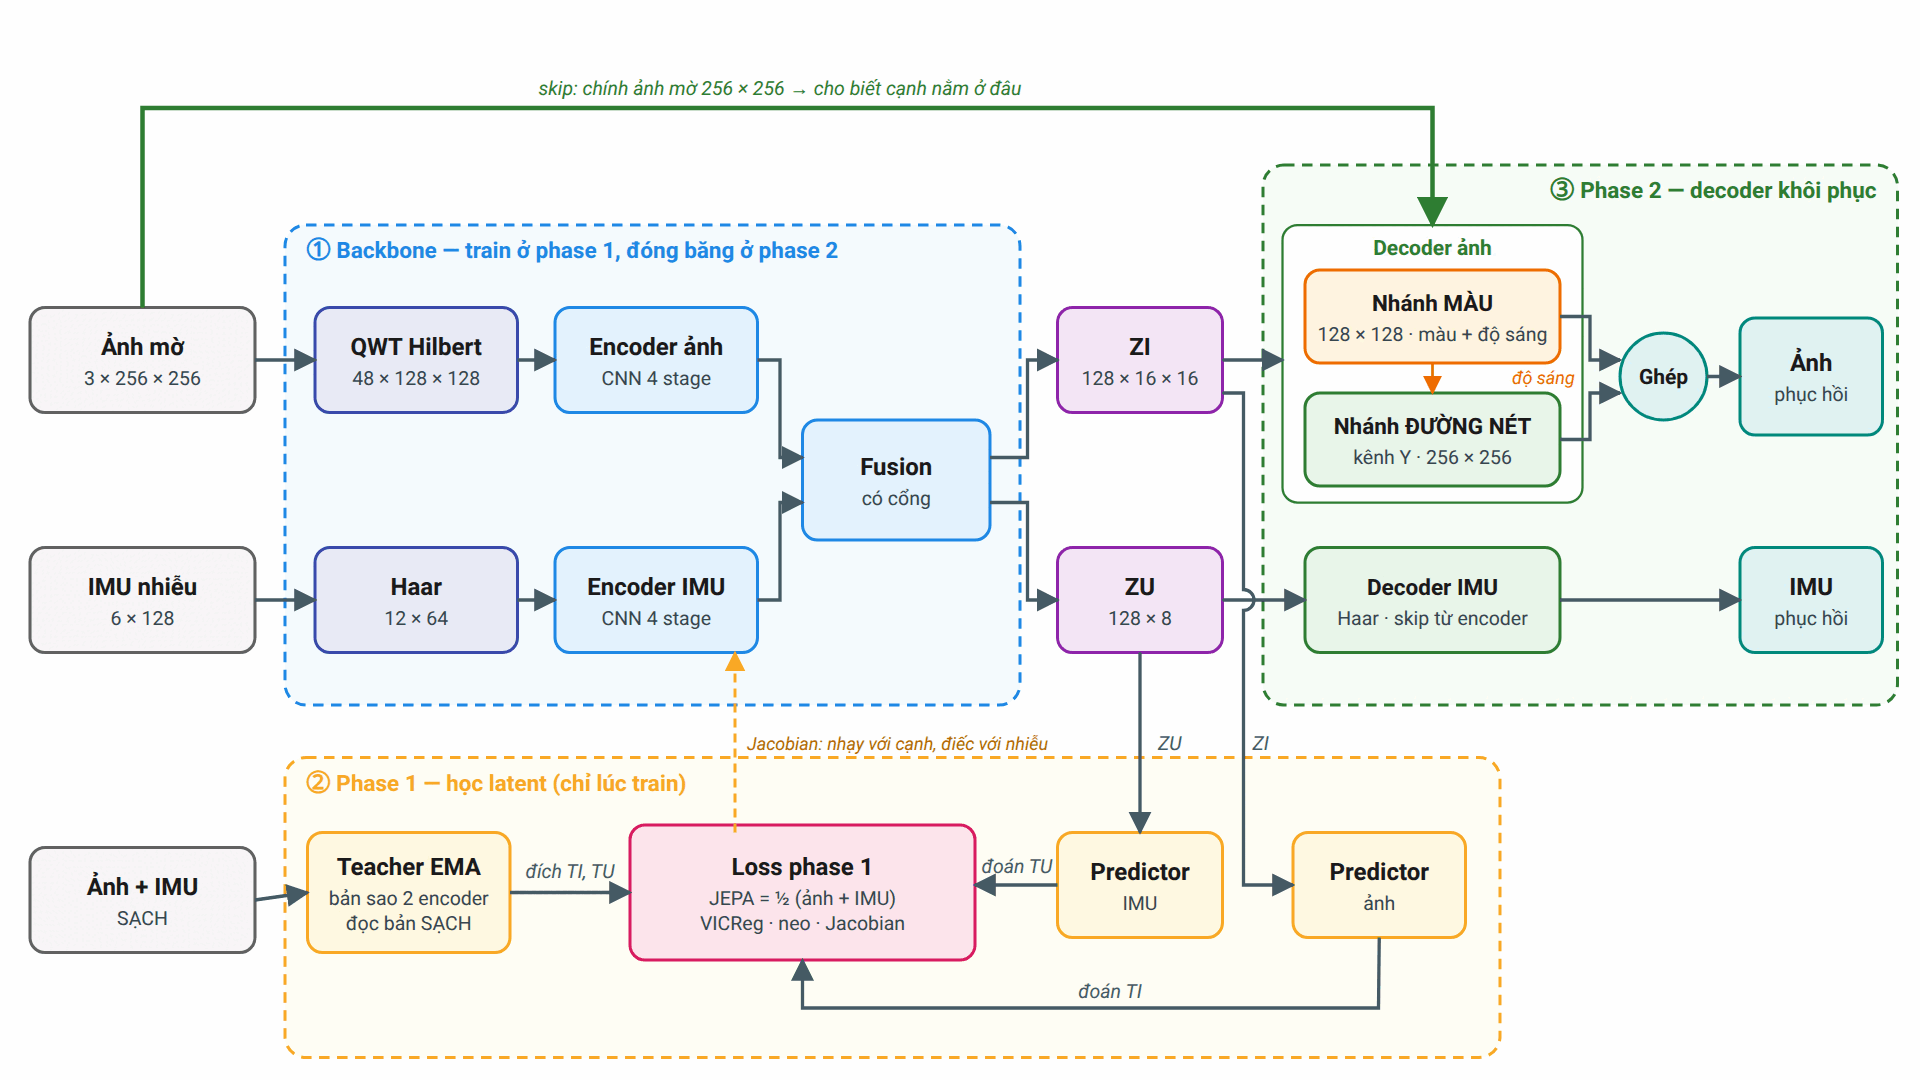

1. **① Backbone (xanh dương).** Ảnh mờ qua **QWT Hilbert**, IMU nhiễu qua **Haar**; mỗi bên một
   encoder CNN; fusion trộn hai bên thành latent **ZI** (ảnh) và **ZU** (IMU).
2. **② Phase 1 (vàng, chỉ lúc train).** Teacher EMA (bản sao hai encoder) đọc bản **sạch**, cho ra
   đích **TI**, **TU**. Hai predictor riêng: **ZI → đoán TI**, **ZU → đoán TU**. Loss JEPA cùng
   VICReg, decoder neo và **Jacobian** train backbone; Jacobian ép encoder nhạy với đường nét,
   bỏ qua nhiễu.
3. **③ Phase 2 (xanh lá).** Backbone **đóng băng**. Decoder ảnh nhận ZI và **chính ảnh mờ** (skip),
   tách thành nhánh **màu** (128×128) và nhánh **đường nét** trên kênh sáng Y (256×256), rồi ghép.
   Decoder IMU nhận ZU.

## Chạy

Train từ GitHub, source ghim tại commit `4fca15b` để recipe không tự đổi giữa phiên.
**Phase 1** (JEPA + Jacobian, 5.000 update) **dùng lại** checkpoint của p5 nếu tìm thấy
— Cell 4 tự dò trong `/kaggle/working` và các Input; không thấy thì train mới.
**Phase 2** (5.000 update): decoder ảnh **tách màu và đường nét** — nhánh màu khôi phục
màu và độ sáng nền ở 128×128, nhánh đường nét khôi phục mọi cạnh của kênh sáng Y ở
256×256 (ảnh mờ qua skip + latent JEPA), rồi ghép lại; loss màu, loss đường nét và độ
dốc cạnh riêng, cộng loss toàn ảnh. Không dùng GAN. IMU giữ decoder hệ số.

Trước khi chạy: gắn dataset TartanAir V2, bật **Internet** và **GPU T4 x2** trong
Notebook options. Muốn dùng lại phase 1 của p5 ở phiên mới: gắn archive
`p5_modulus_phase*.zip` (đã tải về trước đó) làm Input.

Thứ tự chạy: Cell 1 → 4, **ô kiểm tra** (phải in `OK`), Cell 5, 7, 8 (bỏ qua nếu phase 1
đã có), 9, 10, 11 (bỏ qua nếu probe đã có), **13 (train phase 2)**, 14, 15, 18. Cell 6,
12, 14b, 14c, 16 là tùy chọn.

Archive được tạo ngay sau mỗi phase. **Tải archive hoặc lưu Kaggle Output trước
khi kết thúc phiên**; file trong `/kaggle/working` không tự tồn tại ở phiên mới.
Muốn resume một run dở: giải nén archive, gắn làm Input, đặt `RESUME_RUN` ở Cell 1
trỏ vào `.../outputs/p8_color_edge`. Chỉ dùng checkpoint do bạn tạo và tin cậy.


## Cell 1 — Source và các lựa chọn của phiên


In [ ]:
from pathlib import Path
import gc
import json
import os
import shutil
import subprocess
import sys
import time

cell_started = time.perf_counter()
INPUT = Path('/kaggle/input')
PROJECT = Path('/kaggle/working/qwt_jepa_version3')
REPO_URL = 'https://github.com/leesanghyoek/qwt_jepa_ver4.git'
SOURCE_REF = '4fca15b'
RESUME_RUN = None  # Path('/kaggle/input/<archive-da-giai-nen>/outputs/p8_color_edge')
DATA_ROOT = Path('/kaggle/input/tartanairkhoi/tartanair-v2')
if not DATA_ROOT.is_dir():
    DATA_ROOT = None  # Mount khác: Cell 3 sẽ tự dò.
RUN_TESTS = False  # Chỉ bật khi cần kiểm thử toàn bộ code/GPU.
RUN_PREVIEW = False
RUN_PROBE = True
RUN_ORACLES = False  # Đã có PCA 94%; không cần đo lại mỗi lần train.
FULL_TEST = False    # Chỉ bật sau khi chốt model bằng validation.
DATALOADER_WORKERS = 3  # T4x2 có 4 vCPU; GPU chờ dữ liệu (35% ở 2 worker, RAM 10/30 GB).
                        # 4 worker tranh CPU với tiến trình chính. RAM gần đầy thì hạ về 2.
PIN_MEMORY = True       # Cho phép copy CPU -> GPU bất đồng bộ.

if RESUME_RUN is not None:
    RESUME_RUN = Path(RESUME_RUN)
    revision = RESUME_RUN / 'source_revision.txt'
    assert revision.is_file(), f'Thiếu {revision}'
    SOURCE_REF = revision.read_text().strip()

def git_output(*args):
    return subprocess.check_output(['git', '-C', str(PROJECT), *args], text=True).strip()

if not PROJECT.exists():
    subprocess.run(['git', 'clone', '--branch', 'main', REPO_URL, str(PROJECT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT), 'checkout', '--detach', SOURCE_REF], check=True)
else:
    # PROJECT con lai tu lan chay truoc trong cung session. Ban cu bo qua hoan toan
    # nhanh nay, nen doi SOURCE_REF KHONG co tac dung: checkout van o commit cu va
    # configs/ van la ban cu. Mot run da chay sai het vi dieu nay (encoder_skips
    # doc ra False du config moi ghi true). Fetch va checkout lai cho chac.
    print('PROJECT da ton tai; fetch va checkout lai', SOURCE_REF)
    if git_output('remote', 'get-url', 'origin').removesuffix('.git') != REPO_URL.removesuffix('.git'):
        subprocess.run(['git', '-C', str(PROJECT), 'remote', 'set-url', 'origin', REPO_URL], check=True)
    subprocess.run(['git', '-C', str(PROJECT), 'fetch', '--no-tags', 'origin', 'main'], check=True)
    subprocess.run(['git', '-C', str(PROJECT), 'checkout', '--detach', SOURCE_REF], check=True)

assert (PROJECT / '.git').is_dir(), 'PROJECT không phải Git checkout; chọn session mới.'
assert git_output('remote', 'get-url', 'origin').removesuffix('.git') == REPO_URL.removesuffix('.git')
SOURCE_COMMIT = git_output('rev-parse', 'HEAD')
assert SOURCE_COMMIT == git_output('rev-parse', SOURCE_REF + '^{commit}'), (
    'Checkout khác SOURCE_REF. Dùng session mới; không đổi code giữa run.'
)
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
os.environ['MPLCONFIGDIR'] = str(PROJECT / 'outputs/matplotlib_cache')
os.environ['PYTEST_DISABLE_PLUGIN_AUTOLOAD'] = '1'
(PROJECT / 'source_revision.txt').write_text(SOURCE_COMMIT + '\n', encoding='utf-8')
print('Source:', SOURCE_COMMIT)
print('Resume:', RESUME_RUN)
assert INPUT.is_dir() and any(INPUT.iterdir()), 'Chưa gắn dataset vào /kaggle/input.'
print('Inputs:', [p.name for p in sorted(INPUT.iterdir())])
print('Cell 1 giây:', round(time.perf_counter() - cell_started, 1))


## Cell 2 — Dependency và GPU; kiểm thử đầy đủ chỉ khi RUN_TESTS=True


In [ ]:
cell_started = time.perf_counter()
import importlib.util
import subprocess

packages = {
    'numpy': 'numpy>=1.24', 'PIL': 'Pillow>=10', 'yaml': 'PyYAML>=6',
    'scipy': 'scipy>=1.11', 'matplotlib': 'matplotlib>=3.7',
}
missing = [requirement for module, requirement in packages.items()
           if importlib.util.find_spec(module) is None]
if RUN_TESTS and importlib.util.find_spec('pytest') is None:
    missing.append('pytest>=8')
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)

import torch
# Cell 1 doi sys.path, nhung Python KHONG import lai module da nam trong
# sys.modules. Chay lai Cell 2 sau khi doi repo/commit se lay ban cu. Xoa cache
# truoc khi import de assert ben duoi kiem tra dung thu vua duoc nap.
for _cached in [m for m in sys.modules if m == 'qjepa' or m.startswith('qjepa.')]:
    del sys.modules[_cached]
import qjepa
# So sanh hai duong dan DA resolve. /kaggle/working co the la symlink, luc do
# mot ben resolve mot ben khong se khong bao gio khop.
_qjepa_path = Path(qjepa.__file__).resolve()
assert _qjepa_path.is_relative_to(PROJECT.resolve()), (
    f'qjepa nap tu {_qjepa_path}, khong phai {PROJECT.resolve()}. '
    'Neu duong dan tro vao site-packages: !pip uninstall -y qwt-jepa-v3 roi restart kernel.'
)
assert torch.cuda.is_available(), 'Bật GPU rồi khởi động lại session notebook.'
print('Python:', sys.version)
print('Torch:', torch.__version__, 'CUDA runtime:', torch.version.cuda)
for index in range(torch.cuda.device_count()):
    properties = torch.cuda.get_device_properties(index)
    print(f'GPU {index}:', properties.name,
          '| VRAM GiB:', round(properties.total_memory / 2**30, 2))
print('Số GPU sẽ dùng (gpu_count=auto):', min(2, torch.cuda.device_count()))
if RUN_TESTS:
    subprocess.run([sys.executable, '-m', 'pytest', '-q'], cwd=PROJECT, check=True)
else:
    print('Bỏ qua full pytest; bật RUN_TESTS ở Cell 1 nếu đổi source hoặc cần kiểm thử đầy đủ.')
import numpy as np
import yaml
import matplotlib.pyplot as plt
from IPython.display import display, Image as DisplayImage, FileLink
print('Cell 2 giây:', round(time.perf_counter() - cell_started, 1))


## Cell 3 — Xác nhận nhanh dataset root và vài timeline; Cell 5 kiểm tra toàn bộ


In [ ]:
cell_started = time.perf_counter()
from collections import Counter
from qjepa.data.tartanair import Trajectory, discover_trajectories, audit_trajectory


def candidate_roots(base):
    # Không duyệt hàng chục nghìn file ảnh khi dò thư mục IMU.
    found = Counter()
    for directory, children, files in os.walk(base):
        children[:] = [name for name in children if name != 'image_lcam_front']
        if Path(directory).name != 'imu' or not {'imu_time.npy', 'imu_time.txt'} & set(files):
            continue
        trajectory = Path(directory).parent
        if (trajectory / 'image_lcam_front').is_dir() and len(trajectory.parents) >= 3:
            found[trajectory.parents[2]] += 1
    return found

if DATA_ROOT is None:
    counts = Counter()
    for mount in sorted(INPUT.iterdir()):
        if mount.is_dir():
            counts.update(candidate_roots(mount))
    assert counts, 'Không thấy trajectory nào; kiểm tra dataset đã gắn và đã giải nén.'
    for root, total in counts.most_common():
        print(f'{total:5d} trajectory  {root}')
    DATA_ROOT = counts.most_common(1)[0][0]
    if len(counts) > 1:
        print('Nếu root được chọn sai, đặt DATA_ROOT ở Cell 1 rồi chạy lại.')

DATA_ROOT = Path(DATA_ROOT)
assert DATA_ROOT.is_dir(), f'Thiếu dataset root: {DATA_ROOT}'
# Glob đúng ba tầng env/difficulty/trajectory, không mở các thư mục ảnh.
paths = {}
for pattern in ('*/*/*/imu/imu_time.npy', '*/*/*/imu/imu_time.txt'):
    for timeline in DATA_ROOT.glob(pattern):
        paths.setdefault(timeline.parent.parent, timeline)
if paths:
    trajectories = []
    for path in sorted(paths):
        assert (path / 'image_lcam_front').is_dir(), f'Thiếu ảnh: {path}'
        environment, difficulty, trajectory_id = path.relative_to(DATA_ROOT).parts
        trajectories.append(Trajectory(path, environment, difficulty, trajectory_id))
else:
    # Chỉ dùng đường quét tổng quát khi dataset có split/subfolder khác layout chuẩn.
    trajectories = discover_trajectories(DATA_ROOT)
keys = [trajectory.key for trajectory in trajectories]
assert keys and len(keys) == len(set(keys)), 'Không tìm thấy trajectory hoặc DATA_ROOT đang gộp bản sao.'
hints = {trajectory.split_hint for trajectory in trajectories}
assert len(hints) == 1, f'Split hint không đồng nhất {hints}; DATA_ROOT đang trỏ quá cao.'
print('DATA_ROOT:', DATA_ROOT, '| trajectory:', len(trajectories),
      '| motion key:', len({trajectory.motion_key for trajectory in trajectories}),
      '| split hint:', next(iter(hints)))
print('Difficulty:', dict(Counter(trajectory.difficulty for trajectory in trajectories)))
for trajectory in trajectories[:3]:
    print(audit_trajectory(trajectory, window=128))
del trajectories
gc.collect()
print('Cell 3 giây:', round(time.perf_counter() - cell_started, 1))


## Cell 4 — Cấu hình và resume

Khi resume, Cell 4 chỉ chép checkpoint, config và log; bỏ qua ảnh đánh giá cũ. Chỉ chỉnh số update trước khi bắt đầu run mới. Khi resume, dùng toàn bộ config đã
lưu trong run, không trộn phase 1 cũ vào recipe mới. Hash khác thì dừng và giữ
checkpoint. Cell không tự xóa run. `OUT` là nguồn duy nhất cho mọi đường dẫn sau.


In [ ]:
cell_started = time.perf_counter()
from qjepa.config import load_config, serializable_config, validate_config
from qjepa.training.checkpoints import configuration_hash, load_checkpoint, require_phase1_checkpoint

OUT = PROJECT / 'outputs/p8_color_edge'
MANIFEST = PROJECT / 'manifests/kaggle'
CONFIG = PROJECT / 'configs/kaggle.yaml'
P1_UPDATES = 5000  # giu bang hai run truoc de so sanh co kiem soat
P2_UPDATES = 5000
# p8 chi doi phase 2 (hash phase 1 giong p5), nen dung lai phase 1 cua p5 va tiet
# kiem mot nua thoi gian. 'auto' = tu do: truoc het /kaggle/working (cung phien),
# roi cac Input (archive p5 da giai nen, toi da 3 tang, khong quet dataset anh).
# Khong thay thi train phase 1 moi. Dat mot Path de chi dinh, None de luon train moi.
# Moi kiem tra hash van chay tren ban chep, phase 1 khong khop se bi tu choi.
REUSE_PHASE1_FROM = 'auto'
REUSE_RUN_NAME = 'p5_modulus'

if REUSE_PHASE1_FROM == 'auto':
    candidates = [PROJECT / 'outputs' / REUSE_RUN_NAME]
    for depth in ('*', '*/*', '*/*/*'):
        candidates += sorted(p.parent.parent for p in
                             INPUT.glob(f'{depth}/outputs/{REUSE_RUN_NAME}/phase1/last.pt'))
    REUSE_PHASE1_FROM = next((c for c in candidates if (c / 'phase1/last.pt').is_file()), None)
    if REUSE_PHASE1_FROM is None and RESUME_RUN is None and not (OUT / 'phase1/last.pt').exists():
        print(f'!!! KHONG tim thay phase 1 cua {REUSE_RUN_NAME} (da tim /kaggle/working va /kaggle/input).')
        print('!!! Cell 8 se TRAIN PHASE 1 MOI (5000 update, them vai gio GPU).')
        print('!!! Muon tiet kiem: dung lai, gan archive p5 lam Input roi chay lai Cell 4.')

# Recipe nam trong configs/kaggle_tartanair_v2.yaml. Cell nay chi ghi de nhung
# thu thuoc ve PHIEN CHAY (so update, duong dan, thiet bi) — khong ghi de cong
# thuc. Ban cu hardcode ca encoder_skips/imu_variation_weight o day, nen sua file
# config khong co tac dung va mot run da chay sai het: encoder_skips ve False du
# config ghi true, va imu_variation_weight ket o 0.5 du config ghi 2.0.
config = serializable_config(load_config(PROJECT / 'configs/kaggle_tartanair_v2.yaml'))
config['phase1']['max_successful_updates'] = P1_UPDATES
config['phase2']['max_successful_updates'] = P2_UPDATES
if RESUME_RUN is not None:
    saved = RESUME_RUN / 'config.yaml'
    assert saved.is_file(), 'Resume cần config.yaml đầy đủ trong archive của notebook này.'
    config = yaml.safe_load(saved.read_text())
    for phase in ('phase1', 'phase2'):
        resolved = RESUME_RUN / phase / 'resolved_config.yaml'
        if resolved.is_file():
            previous = yaml.safe_load(resolved.read_text())
            assert configuration_hash(previous, phase) == configuration_hash(config, phase), (
                f'Archive chứa config không khớp {phase}.'
            )
    if not OUT.exists():
        # Resume chỉ cần checkpoint, config và log; không sao chép các ảnh/eval cũ.
        keep = ('config.yaml', 'source_revision.txt',
                'phase1/last.pt', 'phase1/train.jsonl', 'phase1/resolved_config.yaml',
                'phase2/last.pt', 'phase2/best_joint_validation.pt',
                'phase2/best_blur_validation.pt', 'phase2/best_guarded_validation.pt',
                'phase2/train.jsonl', 'phase2/resolved_config.yaml',
                'phase2/guard_reference.json')
        restored = []
        for name in keep:
            source = RESUME_RUN / name
            if source.is_file():
                destination = OUT / name
                destination.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(source, destination)
                restored.append(name)
        print('Đã khôi phục file cần để resume:', restored)
    else:
        print('OUT đã tồn tại: dùng bản local; không ghi đè từ archive.')

if REUSE_PHASE1_FROM is not None and RESUME_RUN is None and not (OUT / 'phase1/last.pt').exists():
    source = Path(REUSE_PHASE1_FROM) / 'phase1'
    assert (source / 'last.pt').is_file(), (
        f'Khong thay {source}/last.pt. Dat REUSE_PHASE1_FROM = None de train phase 1 moi, '
        "hoac 'auto' de tu do archive p5.")
    # Chep ca thu muc: Cell 9 va Cell 11 doc them log, bank validation va duong cong.
    shutil.copytree(source, OUT / 'phase1', dirs_exist_ok=True)
    print('Dung lai phase 1 tu', source)
    print('  cac kiem tra hash ben duoi va o Cell 8 van chay tren ban chep —',
          'phase 1 khong khop se bi tu choi, khong am tham dung sai.')

config['data'].update(root=str(DATA_ROOT), manifest_dir=str(MANIFEST),
                      num_workers=DATALOADER_WORKERS, pin_memory=PIN_MEMORY)
config['runtime'].update(output_dir=str(OUT), device='cuda', gpu_count='auto')
validate_config(config)
for phase in ('phase1', 'phase2'):
    resolved = OUT / phase / 'resolved_config.yaml'
    if resolved.is_file():
        previous = yaml.safe_load(resolved.read_text())
        assert configuration_hash(previous, phase) == configuration_hash(config, phase), (
            f'{phase}: cấu hình khác run đang có. Chọn OUT mới hoặc dùng đúng config cũ.'
        )
OUT.mkdir(parents=True, exist_ok=True)
revision = OUT / 'source_revision.txt'
if revision.exists():
    assert revision.read_text().strip() == SOURCE_COMMIT, 'OUT thuộc source khác.'
revision.write_text(SOURCE_COMMIT + '\n', encoding='utf-8')
encoded = yaml.safe_dump(config, sort_keys=False)
CONFIG.write_text(encoded, encoding='utf-8')
(OUT / 'config.yaml').write_text(encoded, encoding='utf-8')
PHASE1 = OUT / 'phase1/last.pt'
PHASE2 = OUT / 'phase2/last.pt'
BEST = OUT / 'phase2/best_joint_validation.pt'
for phase, fields in {
    'phase1': ('max_successful_updates', 'coefficient_reconstruction_loss_weight', 'reconstruction_detail_weight'),
    'phase2': ('max_successful_updates', 'encoder_skips', 'residual_sees_input', 'smooth_l1_beta',
               'reconstruction_detail_weight', 'imu_variation_weight', 'detail_energy_weight',
               'image_detail_loss', 'image_detail_source', 'image_decoder',
               'split_color_scale', 'split_gradient_weight'),
}.items():
    print(phase, {key: config[phase][key] for key in fields})
print('OUT:', OUT)
print('workers:', config['data']['num_workers'], '| pin_memory:', config['data']['pin_memory'])

def run_cli(*arguments):
    command = [sys.executable, '-u', '-m', 'qjepa', *map(str, arguments)]
    print('Running:', ' '.join(command), flush=True)
    subprocess.run(command, cwd=PROJECT, check=True)

def run_tool(script, output, *arguments):
    command = [sys.executable, '-u', str(script), *map(str, arguments)]
    output = Path(output)
    output.parent.mkdir(parents=True, exist_ok=True)
    print('Running:', ' '.join(command), flush=True)
    with output.open('w', encoding='utf-8') as log:
        process = subprocess.Popen(command, cwd=PROJECT, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True, bufsize=1)
        try:
            for line in process.stdout:
                print(line, end='', flush=True)
                log.write(line)
            result = process.wait()
        except BaseException:
            process.terminate()
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                process.kill()
                process.wait()
            raise
        finally:
            process.stdout.close()
        if result:
            raise subprocess.CalledProcessError(result, command)
print('Cell 4 giây:', round(time.perf_counter() - cell_started, 1))


## Kiểm tra trước khi train — recipe đã thật sự tới model chưa
Chạy ngay sau Cell 4, **trước** Cell 8. So giá trị trong file recipe với config
thật sự sẽ đưa vào model. Hai lần trước recipe không tới được model và chỉ
phát hiện sau khi train xong.

In [ ]:
import subprocess, yaml
from pathlib import Path

PROJECT = Path(globals().get('PROJECT', '/kaggle/working/qwt_jepa_version3'))
g = lambda *a: subprocess.check_output(['git', '-C', str(PROJECT), *a], text=True).strip()

print('HEAD        :', g('rev-parse', '--short', 'HEAD'))
print('commit      :', g('log', '-1', '--format=%s')[:70])
print('origin      :', g('remote', 'get-url', 'origin'))
print('RESUME_RUN  :', globals().get('RESUME_RUN'))
print('phase 1     :', 'DUNG LAI tu ' + str(globals().get('REUSE_PHASE1_FROM'))
      if (Path(str(globals().get('OUT', ''))) / 'phase1/last.pt').exists() else 'train moi')
print('OUT         :', globals().get('OUT'))

recipe = PROJECT / 'configs/kaggle_tartanair_v2.yaml'
# load_config giai 'extends': cac khoa ResNet nam trong pipeline_v3.yaml, doc YAML
# tho se bao LECH gia.
from qjepa.config import load_config
on_disk = load_config(recipe)['phase2']
live = globals().get('config', {}).get('phase2', {})

print(f"\n{'khoá':<28}{'trong file':>14}{'config đang dùng':>20}")
ok = True
for key in ('image_decoder', 'split_color_width', 'split_edge_width', 'split_edge_blocks',
            'split_color_scale', 'split_illumination_scale', 'split_gradient_weight',
            'encoder_skips', 'imu_variation_weight', 'image_detail_loss', 'image_detail_source', 'skip_gating',
            'decoder_input', 'reconstruction_detail_weight', 'detail_energy_weight'):
    a, b = on_disk.get(key, '—'), live.get(key, '—')
    flag = '' if a == b else '   <-- LỆCH'
    if a != b: ok = False
    print(f'{key:<28}{a!s:>14}{b!s:>20}{flag}')

want = {'image_decoder': 'split_color_edge', 'split_gradient_weight': 1.0, 'encoder_skips': True, 'imu_variation_weight': 2.0,
        'image_detail_loss': 'coefficient', 'image_detail_source': 'restored_image',
        'detail_energy_weight': 1.0}
bad = {k: live.get(k) for k, v in want.items() if live.get(k) != v}
print()
if bad:
    print('DỪNG LẠI — chưa đúng recipe:', bad, '| cần:', want)
    print('  HEAD không phải 4fca15b  -> chạy lại Cell 1 (giờ nó tự fetch+checkout)')
    print('  hoặc RESUME_RUN khác None -> đặt None, nó nạp đè config từ archive cũ')
else:
    print('OK — recipe đã tới model. Train được.')


## Cell 5 — Manifest

Manifest chỉ tạo lần đầu; khi resume Cell 5 dùng bản trong archive nếu root khớp. Manifest được tạo từ cùng dữ liệu, seed và config; CLI kiểm tra hash với checkpoint
khi resume. Đường dẫn dataset cũng thuộc manifest hash: gắn cùng mount như phiên
cũ khi resume. Đổi mount không tương thích thì cần xử lý manifest trước khi train.


In [ ]:
cell_started = time.perf_counter()
manifest_files = ('meta.json', 'train.csv', 'valid.csv', 'test.csv')
if RESUME_RUN is not None and not all((MANIFEST / name).is_file() for name in manifest_files):
    archived_manifest = RESUME_RUN.parent.parent / 'manifests/kaggle'
    archived_meta = archived_manifest / 'meta.json'
    if archived_meta.is_file():
        previous_meta = json.loads(archived_meta.read_text())
        if (Path(previous_meta['root']).resolve() == DATA_ROOT.resolve()
                and all((archived_manifest / name).is_file() for name in manifest_files)):
            MANIFEST.mkdir(parents=True, exist_ok=True)
            for name in manifest_files:
                shutil.copy2(archived_manifest / name, MANIFEST / name)
            print('Khôi phục manifest đã kiểm tra root từ archive.')
if not all((MANIFEST / name).is_file() for name in manifest_files):
    print('Tạo manifest lần đầu: phải duyệt toàn bộ trajectory và timeline.')
    run_cli('build-manifest', '--config', CONFIG, '--data-root', DATA_ROOT, '--output', MANIFEST)
from qjepa.data import read_manifest
manifest = read_manifest(MANIFEST)
meta = manifest['meta']
assert Path(meta['root']).resolve() == DATA_ROOT.resolve(), 'Manifest thuộc dataset root khác.'
print('Manifest hash:', meta['manifest_hash'])
print('Trajectory theo split:', {name: len(keys) for name, keys in meta['trajectories_per_split'].items()})
counts = meta['samples_per_split']
print('Ảnh theo split:', counts)
assert counts['train'] >= 8 and counts['valid'] >= 2 and counts['test'] > 0, counts
train_keys = {sample.trajectory_key for sample in manifest['samples']['train']}
assert len(train_keys) >= config['data']['minimum_trajectories_per_batch'], 'Train thiếu trajectory đa dạng.'
motion_groups = [{(row.environment, row.trajectory_id) for row in manifest['samples'][split]}
                 for split in ('train', 'valid', 'test')]
assert all(motion_groups[i].isdisjoint(motion_groups[j]) for i in range(3) for j in range(i + 1, 3))
if counts['valid'] < 64:
    print('Validation có <64 mẫu: bank dùng toàn bộ, rank bị giới hạn bởi N-1.')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(list(counts), list(counts.values()))
axes[0].set(title='Paired samples per split', ylabel='Samples')
axes[1].bar(meta['normalization']['channels'], meta['normalization']['std'])
axes[1].set(title='Clean train IMU std (mixed SI units)')
fig.tight_layout()
plt.show()
plt.close(fig)
MANIFEST_HASH = meta["manifest_hash"]
del manifest, meta, train_keys, motion_groups
gc.collect()
print('Cell 5 giây:', round(time.perf_counter() - cell_started, 1))


## Cell 6 — Preview corruption (tùy chọn, không phải ảnh model)


In [ ]:
def preview_corruption():
    import numpy as np
    from qjepa.cli import _dataset

    CHANNELS = ('ax', 'ay', 'az', 'gx', 'gy', 'gz')
    preview_dataset = _dataset(config, read_manifest(MANIFEST), 'valid', fixed_realization=False)
    rng = np.random.default_rng()                      # khong seed -> moi lan chay khac nhau
    preview_dataset.set_realization(int(rng.integers(1, 10**6)))
    picks = rng.choice(len(preview_dataset), size=min(6, len(preview_dataset)), replace=False)
    samples = [preview_dataset[int(i)] for i in picks]
    print('realization', preview_dataset.realization, '| sample', list(map(int, picks)))

    fig, axes = plt.subplots(2, 6, figsize=(17, 6))
    for column, sample in enumerate(samples):
        image = sample['corruption']['image']
        blur = [name for name, on in (('defocus', image['defocus']), ('motion', image['motion']),
                                      ('downsample', image['downsample'])) if on]
        for row, key in enumerate(('image_clean', 'image_noisy')):
            axes[row, column].imshow(sample[key].permute(1, 2, 0).numpy())
            axes[row, column].axis('off')
        axes[0, column].set_title(f"#{int(picks[column])} {sample['trajectory_key']}\nmean {sample['image_clean'].mean():.2f}",
                                  fontsize=8)
        axes[1, column].set_title(
            ('CLEAN' if image['clean'] else '+'.join(blur) or 'khong nhoe')
            + f"\ngain {image['exposure_gain']:.2f} | mean {sample['image_noisy'].mean():.2f}",
            fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    sample = samples[0]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, name in zip(axes[:2], ('image_clean', 'image_noisy')):
        ax.imshow(sample[name].permute(1, 2, 0).numpy())
        ax.set_title(name)
        ax.axis('off')
    error = (sample['image_clean'] - sample['image_noisy']).abs().mean(0)
    axes[2].imshow(error, cmap='magma', vmin=0, vmax=float(error.max()))
    axes[2].set_title(f'Mean absolute RGB error (max {error.max():.2f})')
    axes[2].axis('off')
    plt.show()
    plt.close(fig)

    t = sample['imu_times'].numpy()
    t = t - t[0]
    clean, noisy = sample['imu_clean_phys'].numpy(), sample['imu_noisy_phys'].numpy()
    fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
    for channel, ax in enumerate(axes.T.flat):
        ax.plot(t, clean[:, channel], label='clean')
        ax.plot(t, noisy[:, channel], alpha=0.7, label='corrupted')
        ax.set(title=CHANNELS[channel], ylabel='m/s²' if channel < 3 else 'rad/s', xlabel='Time (s)')
        ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    residual = noisy - clean
    freq = np.fft.rfftfreq(len(t), float(np.median(np.diff(t))))
    fig, ax = plt.subplots(figsize=(13, 3.5))
    for channel in range(6):
        ax.semilogy(freq, np.abs(np.fft.rfft(residual[:, channel])) + 1e-9,
                    label=CHANNELS[channel], alpha=0.8)
    ax.set(title='Pho nhieu IMU them vao (corrupted - clean)', xlabel='Hz', ylabel='|FFT|')
    ax.legend(ncol=6, fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    above5 = (np.abs(np.fft.rfft(residual, axis=0))[freq > 5] ** 2).sum()
    print(f"Nang luong nhieu tren 5 Hz: {100 * above5 / max(float((np.abs(np.fft.rfft(residual, axis=0)) ** 2).sum()), 1e-12):.0f}%")
    print(json.dumps(sample['corruption'], indent=2))

if RUN_PREVIEW:
    preview_corruption()
    gc.collect()
else:
    print("Bỏ qua preview; bật RUN_PREVIEW ở Cell 1 nếu cần.")


## Cell 7 — Hàm lưu archive

Chạy cell này một lần để định nghĩa hàm. Các cell sau tự gọi khi mỗi phase xong.
Có thể gọi `export_run()` sau khi dừng train để tải checkpoint gần nhất.
Archive chứa toàn bộ run, config, manifest và source; không chứa dataset gốc.


In [ ]:
import zipfile

def export_run():
    assert PHASE1.is_file(), 'Chưa có checkpoint phase 1 để lưu.'
    export_dir = Path('/kaggle/working')
    stage = 'phase2' if PHASE2.is_file() else 'phase1'
    archive_path = export_dir / f'{OUT.name}_{stage}.zip'
    temporary = archive_path.with_suffix('.zip.tmp')
    include = [OUT, MANIFEST, CONFIG, PROJECT / 'source_revision.txt',
               PROJECT / 'qjepa', PROJECT / 'configs', PROJECT / 'tools',
               PROJECT / 'pyproject.toml', PROJECT / 'README.md']
    seen = set()
    with zipfile.ZipFile(temporary, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=1) as bundle:
        for path in include:
            for file in sorted(path.rglob('*')) if path.is_dir() else [path]:
                if not file.is_file() or '__pycache__' in file.parts or file.suffix == '.tmp':
                    continue
                name = file.relative_to(PROJECT).as_posix()
                if name not in seen:
                    bundle.write(file, name)
                    seen.add(name)
    temporary.replace(archive_path)
    print('Archive:', archive_path, '| GiB:', round(archive_path.stat().st_size / 2**30, 3))
    print('Tải file này hoặc lưu Kaggle Output trước khi kết thúc phiên.')
    display(FileLink(archive_path.name, url_prefix='/kaggle/working/'))
    return archive_path


## Cell 8 — Train phase 1

Đã có checkpoint phù hợp thì resume; đã đủ update thì bỏ qua train. Hash lệch thì
dừng, không xóa checkpoint. Run chết trước checkpoint đầu được đổi tên để giữ log.
Notebook dùng 1 worker để corruption chạy song song với GPU. Hai worker từng tăng
RAM mạnh; theo dõi `RSS ... + worker ...` ở mỗi checkpoint. Nếu RAM tiến gần giới
hạn, interrupt sau checkpoint, đặt `DATALOADER_WORKERS=0`, chạy lại Cell 4 và
resume. Worker/pin memory nằm ngoài configuration hash nên không mất checkpoint.


In [ ]:
def train_phase(phase):
    current = yaml.safe_load(CONFIG.read_text())
    for name in ('phase1', 'phase2'):
        assert configuration_hash(current, name) == configuration_hash(config, name), (
            'Config trên đĩa khác biến notebook; chạy lại Cell 4.'
        )
    folder = OUT / phase
    checkpoint = folder / 'last.pt'
    maximum = config[phase]['max_successful_updates']
    if checkpoint.exists():
        payload = load_checkpoint(checkpoint, 'cpu')
        metadata = dict(payload['metadata'])
        update = int(payload['successful_updates'])
        del payload
        gc.collect()
        assert metadata['configuration_hash'] == configuration_hash(config, phase), (
            f'{phase}: checkpoint khác config; chọn run mới, không xóa checkpoint này.'
        )
        assert metadata['manifest_hash'] == MANIFEST_HASH, 'Manifest khác checkpoint.'
        if phase == 'phase2':
            assert metadata['frozen_backbone_hash'] == PHASE1_BACKBONE_HASH, 'Phase 2 thuộc backbone khác.'
        assert update <= maximum, 'Checkpoint có nhiều update hơn config.'
        if update == maximum:
            print(f'{phase}: đã hoàn tất {update}/{maximum}, bỏ qua train.')
            return
        print(f'{phase}: resume từ {update}/{maximum}')
    elif (folder / 'train.jsonl').exists():
        archived = folder.with_name(phase + '_incomplete_' + str(time.time_ns()))
        folder.rename(archived)
        print('Chưa có checkpoint; giữ log run dở tại', archived)
    arguments = ['train-' + phase, '--config', CONFIG, '--manifest', MANIFEST, '--output', OUT]
    if phase == 'phase2':
        arguments += ['--backbone-checkpoint', PHASE1]
    if checkpoint.exists():
        arguments += ['--resume', checkpoint]
    started = time.perf_counter()
    run_cli(*arguments)
    print(phase, 'phút:', round((time.perf_counter() - started) / 60, 1))

train_phase('phase1')


## Cell 9 — Gate, đường cong và loss neo phase 1


In [ ]:
payload = load_checkpoint(PHASE1, 'cpu')
require_phase1_checkpoint(payload)
assert payload['successful_updates'] == config['phase1']['max_successful_updates']
assert payload['metadata']['configuration_hash'] == configuration_hash(config, 'phase1')
assert payload['metadata']['manifest_hash'] == MANIFEST_HASH
print('Gate:', payload['metadata']['latent_gate_status'])
print('Reasons:', payload.get('latent_metrics', {}).get('gate_reasons'))
PHASE1_BACKBONE_HASH = payload['metadata']['backbone_hash']
gate = payload['metadata']['latent_gate_status']
del payload
gc.collect()
run_cli('plot-training', '--run-dir', OUT / 'phase1')
for name in ('training_curves.png', 'latent_diagnostics.png'):
    display(DisplayImage(filename=str(OUT / 'phase1' / name)))

def print_anchor_history():
    last = None
    def show(row):
        print(f"update {row['successful_updates']:>6} | ảnh {row['reconstruction_image']:.4f}"
              f" | ảnh detail {row['reconstruction_image_detail']:.4f}"
              f" | IMU {row['reconstruction_imu']:.4f}"
              f" | IMU detail {row['reconstruction_imu_detail']:.4f}")
    with (OUT / 'phase1/train.jsonl').open() as stream:
        for line in stream:
            if not line.strip():
                continue
            row = json.loads(line)
            if 'reconstruction_image' in row:
                last = row
                if (int(row['successful_updates']) - 1) % 1000 == 0:
                    show(row)
    if last is not None:
        print('Cuối cùng:')
        show(last)
    else:
        print('Không có record neo trong log.')
print_anchor_history()
assert gate == 'PASS', 'Gate chưa PASS; xem log, không sửa metadata để vượt gate.'


## Cell 10 — Lưu phase 1 ngay khi train xong

Archive này đủ checkpoint để không mất phase 1 nếu phiên ngắt ở bước probe/phase 2.
Sau khi probe xong, archive sẽ được cập nhật thêm báo cáo.


In [ ]:
export_run()


## Cell 11 — Probe latent phase 1

So với mốc cũ: ảnh 53%, IMU cả cửa sổ 43%. Probe hiện dùng đầu vào **sạch** và
MAE pixel, chưa đo riêng cạnh hoặc khả năng khôi phục từ ảnh nhiễu. PCA 94% là
mốc tham khảo nén patch sạch, không phải mục tiêu chất lượng bắt buộc của JEPA.


In [ ]:
PROBE_REPORT = OUT / 'phase1/latent_probe_clean.txt'
if RUN_PROBE and PROBE_REPORT.is_file():
    # Phase 1 dung lai tu p5: probe cua dung phase 1 nay da duoc chep sang cung.
    print(f'Probe da co ({PROBE_REPORT}); phase 1 khong doi nen khong do lai.')
    print(PROBE_REPORT.read_text()[-1500:])
elif RUN_PROBE:
    run_tool('tools/latent_probe.py', OUT / 'phase1/latent_probe_clean.txt',
             '--checkpoint', PHASE1, '--manifest', MANIFEST, '--samples', '8000')
    export_run()
else:
    print('Bỏ qua probe.')


## Cell 12 — PCA và IMU oracle (tùy chọn, chỉ chạy một lần nếu cần)


In [ ]:
if RUN_ORACLES:
    run_tool('tools/capacity_ceiling.py', OUT / 'diagnostics/capacity_ceiling.txt',
             '--config', CONFIG, '--manifest', MANIFEST, '--samples', '8000')
    run_tool('tools/imu_oracle.py', OUT / 'diagnostics/imu_oracle.txt',
             '--config', CONFIG, '--manifest', MANIFEST, '--split', 'valid', '--batches', '40')
else:
    print('Bỏ qua PCA/oracle: đã có mốc PCA 94% từ phiên trước.')


## Cell 13 — Train phase 2 và lưu checkpoint


In [ ]:
assert PHASE1.is_file(), f'Thiếu {PHASE1}'
assert gate == 'PASS', 'Chạy Cell 9 kiểm tra phase 1 trước.'
train_phase('phase2')
assert BEST.is_file(), f'Thiếu {BEST}'
run_cli('plot-training', '--run-dir', OUT / 'phase2')
display(DisplayImage(filename=str(OUT / 'phase2/training_curves.png')))
export_run()


## Cell 14 — Delta report trên checkpoint tốt nhất

Kiểm tra sai số LH/HL/HH và detail IMU có giảm so với input không. `--ablate-latent`
chạy lại với `ZI/ZU = 0`: ResNet luôn có đường đi vòng qua latent (chính ảnh mờ), nên
đây là phép đo cho biết **latent JEPA đóng góp bao nhiêu** vào ảnh khôi phục.


In [ ]:
assert BEST.is_file(), 'Chạy xong phase 2 trước khi đo.'
run_tool('tools/delta_report.py', OUT / 'phase2/delta_report_valid.txt',
         '--checkpoint', BEST, '--manifest', MANIFEST, '--split', 'valid', '--batches', '40',
         # Dat ZI/ZU = 0: do phan ResNet thuc su lay tu latent JEPA.
         '--ablate-latent')


## Cell 14b — Chẩn đoán blur trên validation rải đều

Không train lại. Nếu Cell 4 báo cấu hình run cũ khác recipe mới, chạy trực tiếp cell này sau Cell 1. Báo cáo dùng 256 frame rải đều trên validation với realization cố định, tách riêng các frame thực sự có blur. PSNR ở đây tính từ MSE gộp nên không bằng trung bình PSNR từng frame của `evaluate`. Cell kế tiếp chọn cặp ảnh–IMU ngẫu nhiên để xem trực quan.


In [ ]:
from pathlib import Path
import os
import subprocess
import sys
import time
from IPython.display import display, Image as DisplayImage, FileLink

PROJECT = Path(globals().get('PROJECT', '/kaggle/working/qwt_jepa_version3'))
OUT = Path(globals().get('OUT', PROJECT / 'outputs/p8_color_edge'))
MANIFEST = Path(globals().get('MANIFEST', PROJECT / 'manifests/kaggle'))
BEST = OUT / 'phase2/best_joint_validation.pt'
assert BEST.is_file(), f'Thiếu checkpoint: {BEST}'
assert (MANIFEST / 'meta.json').is_file(), f'Thiếu manifest: {MANIFEST}'

AUDIT_REF = '4fca15b'
subprocess.run(['git', '-C', str(PROJECT), 'fetch', '--no-tags', 'origin', 'main'], check=True)
audit_source = subprocess.check_output(
    ['git', '-C', str(PROJECT), 'show', f'{AUDIT_REF}:tools/image_blur_audit.py'],
    text=True,
)
AUDIT_SCRIPT = OUT / 'diagnostics/image_blur_audit.py'
AUDIT_SCRIPT.parent.mkdir(parents=True, exist_ok=True)
AUDIT_SCRIPT.write_text(audit_source, encoding='utf-8')
audit_env = os.environ.copy()
audit_env['PYTHONPATH'] = str(PROJECT) + os.pathsep + audit_env.get('PYTHONPATH', '')
AUDIT_JSON = OUT / 'diagnostics/blur_audit_spread_256.json'
subprocess.run(
    [sys.executable, '-u', str(AUDIT_SCRIPT),
     '--checkpoint', str(BEST), '--manifest', str(MANIFEST),
     '--split', 'valid', '--samples', '256', '--device', 'cuda',
     '--output', str(AUDIT_JSON)],
    cwd=PROJECT, env=audit_env, check=True,
)
display(FileLink(str(AUDIT_JSON)))



## Cell 14c — Xem cặp ảnh–IMU ngẫu nhiên; chạy lại cell này để đổi mẫu

Mỗi lần chạy chọn 4 frame validation mới, cùng cửa sổ IMU của từng frame, và một realization nhiễu mới. Nếu validation đủ mẫu, ID sẽ không trùng lượt ngay trước. Panel hiện ba ảnh sạch/hư hại/khôi phục và sáu kênh IMU sạch/hư hại/khôi phục. Mặc định ảnh chỉ blur, IMU hư hại đầy đủ. Seed, ID và thông số nhiễu được lưu trong `preview.json`; báo cáo định lượng ở Cell 14b không đổi. Có thể chạy Cell 14c ngay sau Cell 1 nếu chỉ muốn xem mẫu.


In [ ]:
from pathlib import Path
import os
import subprocess
import sys
import time
from IPython.display import display, Image as DisplayImage, FileLink

PROJECT = Path(globals().get('PROJECT', '/kaggle/working/qwt_jepa_version3'))
OUT = Path(globals().get('OUT', PROJECT / 'outputs/p8_color_edge'))
MANIFEST = Path(globals().get('MANIFEST', PROJECT / 'manifests/kaggle'))
BEST = OUT / 'phase2/best_joint_validation.pt'
assert BEST.is_file(), f'Thiếu checkpoint: {BEST}'
assert (MANIFEST / 'meta.json').is_file(), f'Thiếu manifest: {MANIFEST}'

PREVIEW_REF = '4fca15b'
try:
    preview_source = subprocess.check_output(
        ['git', '-C', str(PROJECT), 'show', f'{PREVIEW_REF}:tools/random_pair_preview.py'],
        text=True, stderr=subprocess.DEVNULL,
    )
except subprocess.CalledProcessError:
    subprocess.run(['git', '-C', str(PROJECT), 'fetch', '--no-tags', 'origin', 'main'], check=True)
    preview_source = subprocess.check_output(
        ['git', '-C', str(PROJECT), 'show', f'{PREVIEW_REF}:tools/random_pair_preview.py'],
        text=True,
    )
PREVIEW_SCRIPT = OUT / 'diagnostics/random_pair_preview.py'
PREVIEW_SCRIPT.parent.mkdir(parents=True, exist_ok=True)
PREVIEW_SCRIPT.write_text(preview_source, encoding='utf-8')
preview_env = os.environ.copy()
preview_env['PYTHONPATH'] = str(PROJECT) + os.pathsep + preview_env.get('PYTHONPATH', '')
PREVIEW_COUNT = 4
PREVIEW_IMAGE_MODE = 'blur_low_light'  # Đổi thành 'full' nếu muốn xem hư hại ảnh tổng hợp.
PREVIEW_IMU_MODE = 'full'
PREVIEW_LIGHT_SCALE = 1.6  # >1 sáng hơn chỉ ở panel này; 1.0 = đúng recipe train
tag = time.strftime('%Y%m%d_%H%M%S') + '_' + str(time.time_ns() % 1_000_000_000)
PAIR_PREVIEW = OUT / f'preview_pairs_{tag}'
subprocess.run(
    [sys.executable, '-u', str(PREVIEW_SCRIPT),
     '--checkpoint', str(BEST), '--manifest', str(MANIFEST),
     '--split', 'valid', '--count', str(PREVIEW_COUNT),
     '--image-mode', PREVIEW_IMAGE_MODE, '--imu-mode', PREVIEW_IMU_MODE,
     '--light-scale', str(PREVIEW_LIGHT_SCALE),
     '--state', str(OUT / 'diagnostics/random_preview_state.json'),
     '--device', 'cuda', '--output', str(PAIR_PREVIEW)],
    cwd=PROJECT, env=preview_env, check=True,
)
for panel in sorted(PAIR_PREVIEW.glob('pair_*.png')):
    display(DisplayImage(filename=str(panel)))
display(FileLink(str(PAIR_PREVIEW / 'preview.json')))
print('Cặp ảnh + IMU:', PAIR_PREVIEW)


## Cell 15 — Đánh giá và bảng so với input

Mặc định full/full trên toàn validation, phù hợp số liệu run trước. Bật `FULL_TEST`
ở Cell 1 khi cần protocol 10 kịch bản trên test sau khi chốt model.
Mỗi lượt tạo thư mục riêng để không đọc nhầm báo cáo của checkpoint cũ.


In [ ]:
tag = time.strftime('%Y%m%d_%H%M%S') + '_' + str(time.time_ns() % 1_000_000_000)
split = 'test' if FULL_TEST else 'valid'
EVAL = OUT / (f'eval_test_{tag}' if FULL_TEST else f'eval_valid_{tag}')
extra = ['--protocol'] if FULL_TEST else ['--image-mode', 'full', '--imu-mode', 'full']
run_cli('evaluate', '--checkpoint', BEST, '--manifest', MANIFEST,
        '--split', split, *extra, '--device', 'cuda', '--output', EVAL,
        '--panels', '6' if FULL_TEST else '2')
results = json.loads((EVAL / 'metrics.json').read_text())
(OUT / 'latest_evaluation.txt').write_text(str(EVAL.relative_to(OUT)) + '\n', encoding='utf-8')
display(DisplayImage(filename=str(EVAL / 'comparison.png')))
for scenario, values in results.items():
    print('\nSCENARIO:', scenario, '| ảnh:', values['image_count'],
          '| hàng IMU:', values['imu_covered_unique_rows'])
    for key in ('image_psnr_db', 'image_ssim', 'image_mae', 'accel_rmse', 'gyro_rmse',
                'accel_variation_rmse', 'gyro_variation_rmse'):
        got, base = values[key], values['baseline_' + key]
        better = got > base if key in {'image_psnr_db', 'image_ssim'} else got < base
        print(f"  {key:<24} input={base:10.6f} -> restored={got:10.6f}  {'TỐT HƠN' if better else 'CHƯA'}")
    # PSNR/SSIM khong phan biet lam net that voi soc. Ca hai la nang luong pho so
    # voi anh sach: 1.00 = nhu anh sach.
    if 'image_edge_power' in values:
        print(f"  {'duong net 4-16px /sach':<24} input={values['baseline_image_edge_power']:10.3f}"
              f" -> restored={values['image_edge_power']:10.3f}  (cang gan 1 cang net)")
        print(f"  {'soc 2px /sach':<24} input={values['baseline_image_stripe_power']:10.3f}"
              f" -> restored={values['image_stripe_power']:10.3f}  (> 1.5 la co soc)")
    if 'image_color_error' in values:
        print(f"  {'sai so mau':<24} input={values['baseline_image_color_error']:10.4f}"
              f" -> restored={values['image_color_error']:10.4f}  (cang thap cang dung mau)")


## Cell 16 — Xem ảnh và trace IMU trong cửa sổ 4 giây
Mỗi lần chạy lấy **kịch bản, panel ảnh, trace IMU và vị trí cửa sổ** khác nhau.
Seed được in ra; truyền lại `show_restoration(seed)` để xem đúng mẫu cũ, hoặc đặt
`SEED = <số>` ở đầu cell.

Chú thích mỗi trục có thêm **tỉ lệ rung** = sai số giữa hai mẫu liền kề chia cho
sai số tổng. Gần `1.0` nghĩa là lỗi là **rung**, không phải lệch — và không số hạng
loss nào chấm điểm theo từng mẫu nhìn thấy được điều đó.

In [ ]:
import secrets

SECONDS = 4.0          # do rong cua so. Tang de nhin xu huong, giam de nhin dao dong.
PANELS = 6             # so panel anh hien thi
SEED = None            # None = moi lan chay mot mau khac; dat so de xem lai dung mau cu

def show_restoration(seed=None):
    seed = secrets.randbelow(1_000_000) if seed is None else int(seed)
    rng = np.random.default_rng(seed)
    print(f'seed {seed}  (chay lai dung mau nay: show_restoration({seed}))')

    scenarios = sorted(results)
    SCENARIO = scenarios[int(rng.integers(len(scenarios)))]
    folder = EVAL / SCENARIO
    assert folder.is_dir(), f'Khong thay {folder}'
    print('Kich ban:', SCENARIO, '| co san:', scenarios)

    paths = sorted((folder / 'images').glob('*.png'))
    chosen = rng.permutation(len(paths))[:PANELS]
    print(f'\n=== {len(chosen)}/{len(paths)} panel anh (ngau nhien) ===')
    for i in sorted(chosen):
        print(paths[i].name)
        display(DisplayImage(filename=str(paths[i])))

    CHANNELS = ('ax', 'ay', 'az', 'gx', 'gy', 'gz')
    SURFACE, INK, INK2 = '#fcfcfb', '#0b0b0b', '#52514e'
    CLEAN, NOISY, RESTORED = '#52514e', '#eb6834', '#2a78d6'

    entries = json.loads((folder / 'imu_index.json').read_text())
    assert entries, 'Khong co trace IMU.'
    entry = entries[int(rng.integers(len(entries)))]
    with np.load(folder / entry['file']) as d:
        times, clean, noisy = d['timestamp'], d['clean'], d['noisy']
        restored, coverage, traj = d['restored'], d['coverage'], str(d['trajectory'])

    idx = np.flatnonzero(coverage)
    assert len(idx) > 0, 'Trace khong co hang covered.'
    # Cua so dat ngau nhien nhung phai nam gon trong phan covered; trace ngan hon
    # SECONDS thi lay tu dau, va neu van qua it diem thi lay het.
    t0, span = times[idx[0]], times[idx[-1]] - times[idx[0]]
    latest = max(0.0, span - SECONDS)
    begin = t0 + (rng.uniform(0.0, latest) if latest > 0 else 0.0)
    w = (times >= begin) & (times <= begin + SECONDS) & coverage
    if w.sum() < 10:
        w = coverage.copy()
    t = times[w] - times[w][0]
    print(f'\n{traj} | trace {entry["file"]} ({len(entries)} trace) '
          f'| covered {int(coverage.sum())} hang | cua so {t[-1]:.1f}s ({w.sum()} diem)')

    fig, axes = plt.subplots(6, 1, figsize=(13, 11), sharex=True,
                             constrained_layout=True, facecolor=SURFACE)
    for ch, ax in enumerate(axes):
        ax.set_facecolor(SURFACE)
        ax.plot(t, noisy[w, ch],    color=NOISY,    lw=1.2, alpha=0.75, label='Nhieu (input)')
        ax.plot(t, clean[w, ch],    color=CLEAN,    lw=2.0, label='Sach (dich)')
        ax.plot(t, restored[w, ch], color=RESTORED, lw=2.0, label='Khoi phuc')

        e_in  = np.sqrt(np.mean((noisy[w, ch]    - clean[w, ch]) ** 2))
        e_out = np.sqrt(np.mean((restored[w, ch] - clean[w, ch]) ** 2))
        # Sai so giua hai mau lien ke: ~1.0 lan sai so tong nghia la RUNG chu
        # khong phai lech, va khong so hang loss theo tung mau nao nhin thay no.
        d_in  = np.sqrt(np.mean(np.diff(noisy[w, ch]    - clean[w, ch]) ** 2))
        d_out = np.sqrt(np.mean(np.diff(restored[w, ch] - clean[w, ch]) ** 2))
        ax.annotate(f"RMSE  input {e_in:.3f}  ->  khoi phuc {e_out:.3f}"
                    f"   {'v' if e_out < e_in else '^'} {abs(1 - e_out / max(e_in, 1e-9)) * 100:.0f}%"
                    f"      rung {d_in / max(e_in, 1e-9):.2f} -> {d_out / max(e_out, 1e-9):.2f}",
                    xy=(0.995, 0.06), xycoords='axes fraction', ha='right', va='bottom',
                    fontsize=8.5, color=INK2)
        ax.set_ylabel(f"{CHANNELS[ch]}\n" + ('m/s2' if ch < 3 else 'rad/s'), fontsize=9, color=INK)
        ax.grid(alpha=0.18, linewidth=0.6)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
        for s in ('left', 'bottom'):
            ax.spines[s].set_color('#d8d7d2')
        ax.tick_params(colors=INK2, labelsize=8)

    axes[-1].set_xlabel('Thoi gian trong cua so (s)', fontsize=9, color=INK)
    axes[0].legend(loc='upper left', bbox_to_anchor=(0, 1.55), ncol=3,
                   frameon=False, fontsize=9.5, labelcolor=INK)
    fig.suptitle(f'{SCENARIO} · IMU cua so {SECONDS:g}s · {traj} · seed {seed}',
                 fontsize=11.5, color=INK, y=1.03)
    plt.show()
    plt.close(fig)

show_restoration(SEED)
gc.collect()


## Cell 17 — Lưu toàn bộ kết quả để tải về

Archive có config, manifest, checkpoint, log, probe, delta report, metrics và panel.
Nếu phiên sắp hết, dừng cell train rồi gọi `export_run()` để lấy checkpoint gần nhất.
Đừng chỉ lưu notebook: output ảnh và log trong notebook không thay thế file `.pt`.


In [ ]:
export_run()


## Cell 18 — Báo cáo log phase 1 + phase 2 (in ra để dán cho agent đọc)
Đọc toàn bộ `train.jsonl` của cả hai phase và in báo cáo dạng text: thành phần loss,
cổng latent, chẩn đoán collapse, độ nhạy encoder theo nhánh, và bảng validation so với
baseline kèm kết luận VƯỢT/THUA từng chỉ số.

Chạy sau khi train xong. `RUN` phải trỏ vào thư mục **chứa** `phase1/` và `phase2/`,
không phải vào chính `phase1/` — CLI tự thêm tên phase vào `--output`.

Nếu checkout đang ghim ở commit cũ chưa có `tools/training_report.py`, cell tự tải bản
mới nhất từ GitHub về `/kaggle/working/`.

In [ ]:
import subprocess
import sys
import urllib.request
from pathlib import Path

# Lấy từ Cell 1/Cell 4 nếu có; nếu chạy session mới thì sửa hai dòng này.
PROJECT = Path(globals().get('PROJECT', '/kaggle/working/qwt_jepa_version3'))
RUN = Path(globals().get('OUT', PROJECT / 'outputs/p8_color_edge'))

# Checkout có thể đang ghim ở commit cũ chưa có tool; lúc đó tải bản mới nhất về.
script = PROJECT / 'tools/training_report.py'
if not script.is_file():
    script = Path('/kaggle/working/training_report.py')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/leesanghyoek/qwt_jepa_ver4/main/tools/training_report.py',
        script)
    print('Checkout chưa có tool; đã tải bản mới nhất về', script)

# RUN phải là thư mục CHỨA phase1/ và phase2/, không phải chính phase1/.
if not any((RUN / f'phase{n}/train.jsonl').is_file() for n in (1, 2)):
    print(f'Không thấy train.jsonl dưới {RUN}. Các run tìm được:')
    found = sorted({p.parent.parent for root in ('/kaggle/working', '/kaggle/input')
                    for p in Path(root).glob('**/phase*/train.jsonl')})
    for candidate in found:
        phases = sorted(q.parent.name for q in candidate.glob('phase*/train.jsonl'))
        print(f'   {candidate}   ({", ".join(phases)})')
    raise SystemExit('Đặt RUN = <một trong các đường dẫn trên> rồi chạy lại cell này.')

result = subprocess.run([sys.executable, '-u', str(script), '--run', str(RUN)],
                        capture_output=True, text=True)
print(result.stdout)
if result.stderr.strip():
    print('--- stderr ---')
    print(result.stderr)

report = Path('/kaggle/working/training_report.txt')
report.write_text(result.stdout, encoding='utf-8')
print(f'Đã lưu {report}  ({len(result.stdout)} ký tự) — tải về hoặc copy phần in ở trên.')
try:
    from IPython.display import FileLink, display
    display(FileLink(str(report)))
except Exception:
    pass
